# 06 — Évaluation finale du modèle
**Projet** : ObRail MSPR 2025-2026 

**Objectif** : Évaluation consolidée du modèle LightGBM optimisé sur le jeu de test. Ce notebook rassemble en un seul endroit les métriques finales, la matrice de confusion, la courbe ROC et la courbe précision-rappel. C'est la version notebook du script `src/evaluate.py`.

**Entrées** : `models/best_model_optimized.joblib`, `data/processed/X_test.csv`, `y_test.csv`

## 0. Imports et configuration

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, precision_score, recall_score,
)

SEED = 42
np.random.seed(SEED)

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for folder in [cwd] + list(cwd.parents):
        if (folder / 'data').exists() and (folder / 'src').exists() and (folder / 'models').exists():
            return folder
    raise FileNotFoundError('Racine du projet introuvable.')

ROOT          = find_project_root()
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR    = ROOT / 'models'
EVAL_DIR      = ROOT / 'evaluation'
PLOT_DIR      = EVAL_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement du modèle et du jeu de test

In [2]:
model  = joblib.load(MODELS_DIR / 'best_model_optimized.joblib')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print(f'Modèle : {type(model).__name__}')
print(f'X_test : {X_test.shape}')
print(f'Taux underserved test : {y_test.mean()*100:.1f}%')

Modèle : LGBMClassifier
X_test : (5040, 38)
Taux underserved test : 19.4%


## 2. Prédictions et métriques globales

In [3]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy':                round(accuracy_score(y_test, y_pred), 4),
    'F1 (classe sous-desservie)': round(f1_score(y_test, y_pred), 4),
    'ROC-AUC':                 round(roc_auc_score(y_test, y_proba), 4),
    'Precision (sous-desservie)': round(precision_score(y_test, y_pred), 4),
    'Recall (sous-desservie)':    round(recall_score(y_test, y_pred), 4),
}

print('Métriques sur le jeu de test :')
for k, v in metrics.items():
    print(f'  {k:30} : {v}')

Métriques sur le jeu de test :
  Accuracy                       : 0.7532
  F1 (classe sous-desservie)     : 0.6033
  ROC-AUC                        : 0.8811
  Precision (sous-desservie)     : 0.4382
  Recall (sous-desservie)        : 0.9683


In [4]:
print('Classification report complet :\n')
print(classification_report(
    y_test, y_pred,
    target_names=['Non sous-desservi', 'Sous-desservi']
))

Classification report complet :

                   precision    recall  f1-score   support

Non sous-desservi       0.99      0.70      0.82      4063
    Sous-desservi       0.44      0.97      0.60       977

         accuracy                           0.75      5040
        macro avg       0.71      0.83      0.71      5040
     weighted avg       0.88      0.75      0.78      5040



**Lecture des résultats**

Le recall de 0.97 sur la classe sous-desservie signifie que le modèle détecte la quasi-totalité des routes réellement sous-desservies. La précision de 0.44 indique en revanche un nombre important de faux positifs. Ce compromis est assumé : dans une logique d'aide à la décision pour ObRail, manquer une route sous-desservie (faux négatif) est plus coûteux que signaler à tort une route correctement desservie (faux positif).

## 3. Matrice de confusion

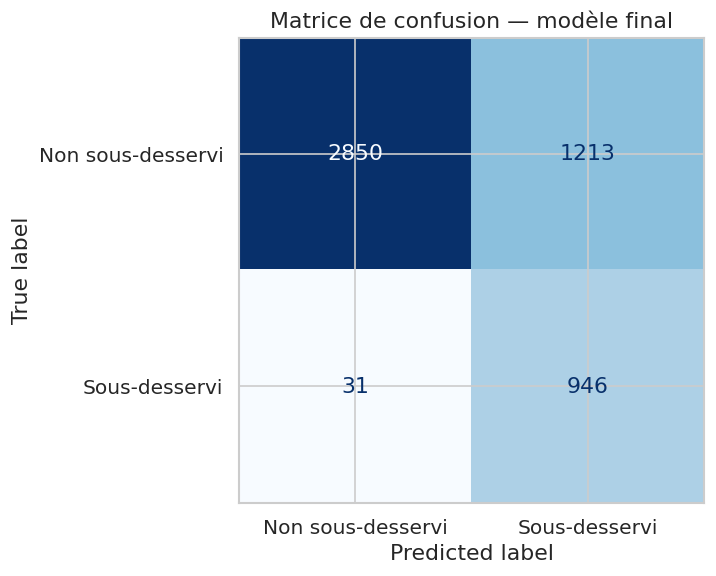

Vrais négatifs  : 2850
Faux positifs   : 1213
Faux négatifs   : 31
Vrais positifs  : 946


In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non sous-desservi', 'Sous-desservi']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion — modèle final')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_matrix_final.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Vrais négatifs  : {tn}')
print(f'Faux positifs   : {fp}')
print(f'Faux négatifs   : {fn}')
print(f'Vrais positifs  : {tp}')

## 4. Courbe ROC

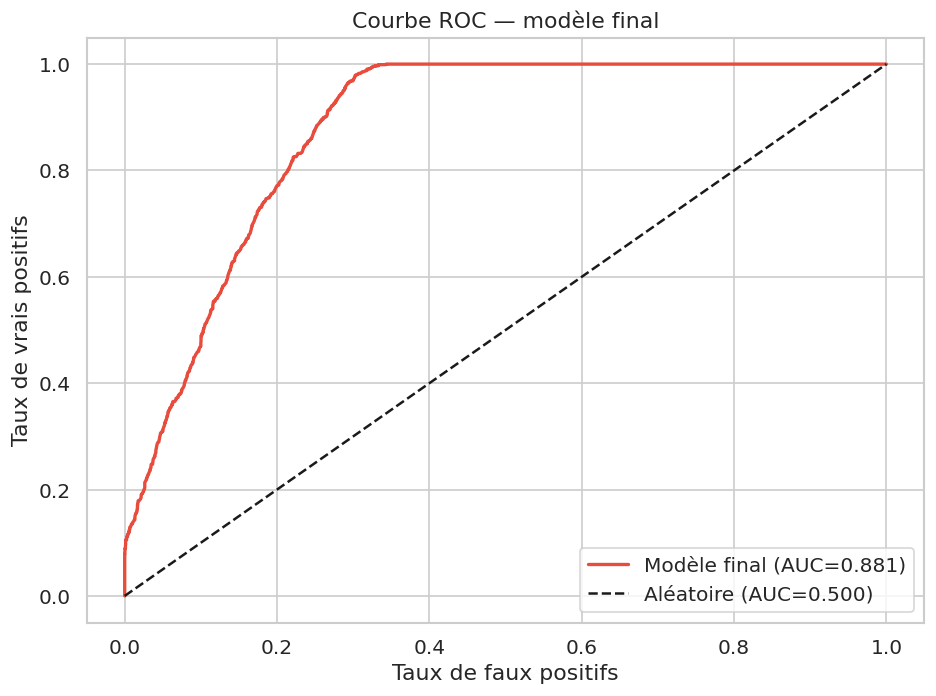

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'Modèle final (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC=0.500)')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbe ROC — modèle final')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'roc_curve_final.png')
plt.show()

# La courbe ROC montre la capacité du modèle à séparer les deux classes.
# Un AUC de 0.88 indique une bonne séparation, bien au-dessus du hasard (0.5).

## 5. Courbe Précision-Rappel

Plus informative que la courbe ROC en contexte de déséquilibre de classes. Elle montre le compromis entre précision (éviter les faux positifs) et rappel (ne pas manquer de vraies routes sous-desservies).

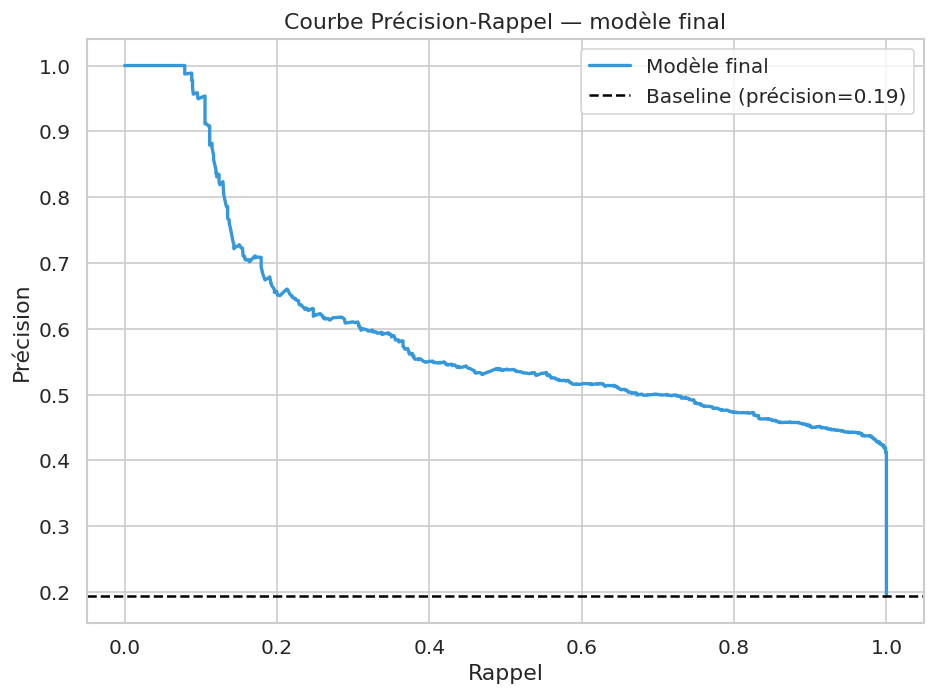

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
prec, rec, _ = precision_recall_curve(y_test, y_proba)

ax.plot(rec, prec, color='#3498db', linewidth=2, label='Modèle final')
ax.axhline(y_test.mean(), color='black', linestyle='--',
           label=f'Baseline (précision={y_test.mean():.2f})')
ax.set_xlabel('Rappel')
ax.set_ylabel('Précision')
ax.set_title('Courbe Précision-Rappel — modèle final')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'precision_recall_final.png')
plt.show()

## 6. Sauvegarde du rapport d'évaluation

In [8]:
report = classification_report(
    y_test, y_pred,
    target_names=['Non sous-desservi', 'Sous-desservi']
)

with open(EVAL_DIR / 'evaluation_report.txt', 'w', encoding='utf-8') as f:
    f.write('Évaluation du modèle final — ObRail MSPR\n')
    f.write('=' * 50 + '\n\n')
    for k, v in metrics.items():
        f.write(f'{k:30} : {v}\n')
    f.write('\n' + report)

print('✅ Rapport sauvegardé → evaluation/evaluation_report.txt')

✅ Rapport sauvegardé → evaluation/evaluation_report.txt


## 7. Synthèse

**Performances finales du modèle LightGBM optimisé**
- Accuracy : 0.75
- F1 (classe sous-desservie) : 0.60
- ROC-AUC : 0.88
- Recall : 0.97 — le modèle manque très peu de routes sous-desservies
- Precision : 0.44 — au prix d'un nombre élevé de faux positifs

**Interprétation pour ObRail**  
Le modèle est conçu pour ne pas manquer de routes sous-desservies (recall élevé), quitte à signaler des routes qui s'avèrent correctement desservies. Ce comportement est adapté à un outil d'aide à la décision où les routes flagguées sont ensuite vérifiées par des experts.

**Plots produits**
- `evaluation/plots/confusion_matrix_final.png`
- `evaluation/plots/roc_curve_final.png`
- `evaluation/plots/precision_recall_final.png`
- `evaluation/evaluation_report.txt`